# Convert Arivis segmentation exports to LightSuite Sample Space v1

This notebook converts **Arivis Vision4D / Blob Finder** exports into formats accepted by
`lightsuite brain import-annotations`:

| LightSuite format | Arivis source | Use when |
|-------------------|---------------|----------|
| `points_csv` | `*-features.xlsx` (center-of-mass columns) | Cell / blob centroids (fast, small) |
| `mask_tiff` | `MASK/*.tiff` (one 2D mask per Z slice) | Full segmentation volume |

**Before you start:** run `lightsuite brain preprocess` on your sample so
`sample_reference.json` exists. Annotations must match that native grid — same shape and
voxel size as the stitched / acquired stack you segmented on (not the 20 µm registration preview).

See also: [Annotation import](https://github.com/ALICe-pipelines/LightSuite/blob/main/docs/annotation_import.md) in the LightSuite docs.

## 0. Configure paths

Edit the variables below for your sample. The **Julie Buron** example paths are filled in as defaults.

In [1]:
from pathlib import Path

# Where LightSuite wrote preprocess outputs (contains sample_reference.json)
SAVE_PATH = Path("/media/gbm/NVME2/ALICe-pipelines-data/JulieBuron/registered_allen")

# Folder with Arivis export (features spreadsheet + MASK subfolder)
ARIVIS_EXPORT = Path(
    "/media/gbm/NVME2/ALICe-pipelines-data/JulieBuron/SegmentationImports/FromArivis"
)

# Where converted LightSuite files will be written
OUTPUT_DIR = Path(
    "/media/gbm/NVME2/ALICe-pipelines-data/JulieBuron/SegmentationImports/converted"
)

LABEL = "arivis_561"  # used in output filenames and YAML import.label

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("save_path:", SAVE_PATH)
print("arivis export:", ARIVIS_EXPORT)
print("output:", OUTPUT_DIR)

save_path: /media/gbm/NVME2/ALICe-pipelines-data/JulieBuron/registered_allen
arivis export: /media/gbm/NVME2/ALICe-pipelines-data/JulieBuron/SegmentationImports/FromArivis
output: /media/gbm/NVME2/ALICe-pipelines-data/JulieBuron/SegmentationImports/converted


## 1. Load the LightSuite native grid contract

After `preprocess`, LightSuite writes `sample_reference.json`. Every imported annotation must
align with this grid:

- **Shape** `(Y, X, Z)` = `shape_yxz` → `(ny, nx, nz)`
- **Voxel size** `[x, y, z]` in µm
- **Indices** are **1-based** — the first voxel center is `(1, 1, 1)`, not `(0, 0, 0)`
- **Axis order** for point CSVs is always `x, y, z`
- Do **not** apply `registration.orientation` yourself; import applies it during the warp

In [2]:
import json

ref_path = SAVE_PATH / "sample_reference.json"
if not ref_path.is_file():
    raise FileNotFoundError(
        f"Missing {ref_path}. Run: uv run lightsuite brain preprocess -c your_config.yaml"
    )

reference = json.loads(ref_path.read_text(encoding="utf-8"))
ny, nx, nz = reference["shape_yxz"]
voxel_um = reference["voxel_um"]

print(json.dumps(reference, indent=2))
print()
print(f"Expected mask shape (Y, X, Z): ({ny}, {nx}, {nz})")
print(f"Point bounds: 1 <= x <= {nx}, 1 <= y <= {ny}, 1 <= z <= {nz}")

{
  "format": "lightsuite_sample_space_v1",
  "sample_name": "Julie",
  "shape_yxz": [
    2048,
    2048,
    1361
  ],
  "voxel_um": [
    6.55,
    6.55,
    5.0
  ],
  "index_base": 1,
  "axis_order": "xyz",
  "coordinate_units": "voxel_indices",
  "orientation_applied": false
}

Expected mask shape (Y, X, Z): (2048, 2048, 1361)
Point bounds: 1 <= x <= 2048, 1 <= y <= 2048, 1 <= z <= 1361


## 2. Inspect the Arivis export

Typical Arivis **Blob Finder** export layout:

```
FromArivis/
├── 1_2ch_1X-features.xlsx    # segment table (COM, volume, …)
└── MASK/
    ├── …_Z00000.tiff         # binary mask for Z index 0
    ├── …_Z00001.tiff
    └── …
```

Filename pattern `1_2ch_1X` usually means: sample **1**, channel **2**, magnification **1×**.
Channel order must match your YAML `source` folder (sorted TIFF list = channel 1, 2, …).

**Coordinate convention:** Arivis COM columns are **0-based pixel indices** (first pixel = 0).
LightSuite requires **+1** on each axis.

In [3]:
mask_dir = ARIVIS_EXPORT / "MASK"
xlsx_files = sorted(ARIVIS_EXPORT.glob("*-features.xlsx"))
mask_files = sorted(mask_dir.glob("*.tif*"))

print("Features spreadsheets:", [p.name for p in xlsx_files])
print("Mask slice count:", len(mask_files))
if mask_files:
    print("First mask:", mask_files[0].name)
    print("Last mask:", mask_files[-1].name)

Features spreadsheets: ['1_2ch_1X-features.xlsx']
Mask slice count: 1361
First mask: 1_2ch_1X-objects_T00000_Z00000.tiff
Last mask: 1_2ch_1X-objects_T00000_Z01360.tiff


## 3. Read Arivis features (XLSX)

Arivis spreadsheets often use non-standard styling that breaks `openpyxl` / `pandas.read_excel`.
We parse the worksheet XML directly from the XLSX zip archive (data only, no styles).

Look for columns like:
- `X (px), Center of Mass (Intensities) #1`
- `Y (px), Center of Mass (Intensities) #1`
- `Z (px), Center of Mass (Intensities) #1`

In [4]:
import zipfile
import xml.etree.ElementTree as ET

NS = "{http://schemas.openxmlformats.org/spreadsheetml/2006/main}"


def _cell_text(cell) -> str:
    is_elem = cell.find(f"{NS}is")
    if is_elem is not None:
        t = is_elem.find(f"{NS}t")
        return t.text if t is not None else ""
    v = cell.find(f"{NS}v")
    return v.text if v is not None else ""


def read_arivis_xlsx(path: Path) -> tuple[list[str], list[list[str]]]:
    """Return (header_row, data_rows) from first worksheet."""
    with zipfile.ZipFile(path) as zf:
        # Arivis may use sheet.xml or sheet1.xml
        sheet_name = "xl/worksheets/sheet.xml"
        if sheet_name not in zf.namelist():
            sheet_name = "xl/worksheets/sheet1.xml"
        root = ET.fromstring(zf.read(sheet_name))

    rows: list[list[str]] = []
    for row in root.findall(f"{NS}sheetData/{NS}row"):
        vals = [_cell_text(c) for c in row.findall(f"{NS}c")]
        rows.append(vals)

    if not rows:
        raise ValueError(f"No rows in {path}")
    return rows[0], rows[1:]


if not xlsx_files:
    raise FileNotFoundError(f"No *-features.xlsx in {ARIVIS_EXPORT}")

XLSX_PATH = xlsx_files[0]
header, data_rows = read_arivis_xlsx(XLSX_PATH)
print(f"Loaded {XLSX_PATH.name}: {len(data_rows)} table rows")
print("Columns:")
for i, col in enumerate(header):
    print(f"  [{i}] {col}")

Loaded 1_2ch_1X-features.xlsx: 9105 table rows
Columns:
  [0] Type
  [1] Name
  [2] Volume, Volume (µm³)
  [3] VoxelCount, Volume
  [4] RelativeVolume, Volume
  [5] X (px), Center of Mass (Intensities) #1
  [6] Y (px), Center of Mass (Intensities) #1
  [7] Z (px), Center of Mass (Intensities) #1


In [5]:
def find_com_columns(header: list[str]) -> tuple[int, int, int]:
    """Map x, y, z column indices from Arivis header names."""
    lowered = [h.lower() for h in header]

    def pick(axis: str) -> int:
        for i, h in enumerate(lowered):
            if axis in h and "center of mass" in h:
                return i
        for i, h in enumerate(lowered):
            if h.startswith(f"{axis} (px)"):
                return i
        raise KeyError(f"Could not find {axis} COM column in header: {header}")

    return pick("x"), pick("y"), pick("z")


ix, iy, iz = find_com_columns(header)
print(f"COM columns: x=[{ix}] {header[ix]}, y=[{iy}] {header[iy]}, z=[{iz}] {header[iz]}")

COM columns: x=[5] X (px), Center of Mass (Intensities) #1, y=[6] Y (px), Center of Mass (Intensities) #1, z=[7] Z (px), Center of Mass (Intensities) #1


## 4. Convert segments → `points.csv`

LightSuite expects a CSV with header columns **`x`**, **`y`**, **`z`** (1-based native voxel indices).
Extra **numeric** columns (volume, voxel count, intensity, …) are kept as optional features.
Text columns such as segment `Name` are skipped automatically at import.

In [6]:
import csv
import numpy as np

POINTS_CSV = OUTPUT_DIR / f"{LABEL}_points.csv"

# Optional extra columns to preserve (adjust if your export differs)
EXTRA_COLS = []
for name in ("Name", "Volume, Volume (µm³)", "VoxelCount, Volume"):
    if name in header:
        EXTRA_COLS.append(name)

type_col = header.index("Type") if "Type" in header else None

points_xyz = []
with POINTS_CSV.open("w", newline="", encoding="utf-8") as fh:
    writer = csv.writer(fh)
    writer.writerow(["x", "y", "z"] + EXTRA_COLS)

    for row in data_rows:
        if type_col is not None and row[type_col] != "Segment":
            continue
        if max(ix, iy, iz) >= len(row):
            continue
        try:
            x = float(row[ix]) + 1.0  # Arivis 0-based → LightSuite 1-based
            y = float(row[iy]) + 1.0
            z = float(row[iz]) + 1.0
        except (TypeError, ValueError):
            continue
        extras = [row[header.index(c)] if c in header else "" for c in EXTRA_COLS]
        writer.writerow([x, y, z] + extras)
        points_xyz.append([x, y, z])

points_xyz = np.asarray(points_xyz, dtype=np.float64)
print(f"Wrote {len(points_xyz)} points → {POINTS_CSV}")
if len(points_xyz):
    print(
        "Ranges (1-based):",
        f"x [{points_xyz[:,0].min():.1f}, {points_xyz[:,0].max():.1f}]",
        f"y [{points_xyz[:,1].min():.1f}, {points_xyz[:,1].max():.1f}]",
        f"z [{points_xyz[:,2].min():.1f}, {points_xyz[:,2].max():.1f}]",
    )

Wrote 9105 points → /media/gbm/NVME2/ALICe-pipelines-data/JulieBuron/SegmentationImports/converted/arivis_561_points.csv
Ranges (1-based): x [190.5, 1800.3] y [18.4, 2048.0] z [1.2, 1359.8]


## 5. Validate points against `sample_reference.json`

Points outside `1 … nx/ny/nz` are dropped at import. Ideally everything should already be in range.

In [7]:
if len(points_xyz):
    in_bounds = (
        (points_xyz[:, 0] >= 1) & (points_xyz[:, 0] <= nx)
        & (points_xyz[:, 1] >= 1) & (points_xyz[:, 1] <= ny)
        & (points_xyz[:, 2] >= 1) & (points_xyz[:, 2] <= nz)
    )
    n_ok = int(in_bounds.sum())
    n_bad = len(points_xyz) - n_ok
    print(f"In bounds: {n_ok}/{len(points_xyz)} ({100 * n_ok / len(points_xyz):.1f}%)")
    if n_bad:
        bad = points_xyz[~in_bounds]
        print(f"WARNING: {n_bad} points out of bounds — will be dropped at import")
        print("First few bad points:", bad[:5])
else:
    print("No points to validate")

In bounds: 9105/9105 (100.0%)


## 6. Stack per-slice masks → single `mask.tif` (optional)

Skip this section if you only need point centroids.

Arivis exports one 2D TIFF per Z plane. LightSuite expects one 3D binary TIFF:

- Shape `(Y, X, Z)` matching `shape_yxz`
- Values `0` / `255` (or `0` / `1`)
- Z-stack layout: one 2D page per Z slice (we write `(Z, Y, X)` pages)

**Note:** for a 2048×2048×1361 stack this is ~5–6 GB. Ensure enough disk space and RAM.

In [8]:
import re
import tifffile

BUILD_MASK = True  # set False to skip mask stacking
MASK_TIFF = OUTPUT_DIR / f"{LABEL}_mask.tif"

if not BUILD_MASK:
    print("Skipping mask build (BUILD_MASK=False)")
elif not mask_files:
    print("No mask slices found — skipping")
else:
    z_pattern = re.compile(r"_Z(\d+)$")

    def z_index(path: Path) -> int:
        m = z_pattern.search(path.stem)
        if m is None:
            raise ValueError(f"Cannot parse Z index from {path.name}")
        return int(m.group(1))

    sorted_masks = sorted(mask_files, key=z_index)
    z_indices = [z_index(p) for p in sorted_masks]
    print(f"Stacking {len(sorted_masks)} slices, Z index {z_indices[0]} … {z_indices[-1]}")

    if z_indices[-1] - z_indices[0] + 1 != len(sorted_masks):
        print("WARNING: Z indices may have gaps — check Arivis export completeness")

    planes = []
    for i, path in enumerate(sorted_masks):
        plane = tifffile.imread(path)
        if plane.ndim != 2:
            raise ValueError(f"Expected 2D mask slice in {path}, got shape {plane.shape}")
        planes.append(plane)
        if i % 200 == 0:
            print(f"  read {i}/{len(sorted_masks)} …")

    stack_zyx = np.stack(planes, axis=0)  # (Z, Y, X)
    print("Stack shape (Z, Y, X):", stack_zyx.shape)
    print("Nonzero voxels:", int(np.count_nonzero(stack_zyx)))

    # LightSuite loads multi-page TIFFs as (Y, X, Z)
    yxz_shape = (stack_zyx.shape[1], stack_zyx.shape[2], stack_zyx.shape[0])
    if yxz_shape != (ny, nx, nz):
        print(
            f"WARNING: mask shape {yxz_shape} != reference ({ny}, {nx}, {nz}). "
            "Import will fail unless shapes match."
        )

    tifffile.imwrite(MASK_TIFF, stack_zyx, photometric="minisblack")
    print(f"Wrote mask → {MASK_TIFF}")

Stacking 1361 slices, Z index 0 … 1360
  read 0/1361 …
  read 200/1361 …
  read 400/1361 …
  read 600/1361 …
  read 800/1361 …
  read 1000/1361 …
  read 1200/1361 …
Stack shape (Z, Y, X): (1361, 2048, 2048)
Nonzero voxels: 773309
Wrote mask → /media/gbm/NVME2/ALICe-pipelines-data/JulieBuron/SegmentationImports/converted/arivis_561_mask.tif


## 7. Quick visual QC (optional)

Overlay a few point projections and/or mask slices on the structural channel to confirm
alignment with the acquisition grid.

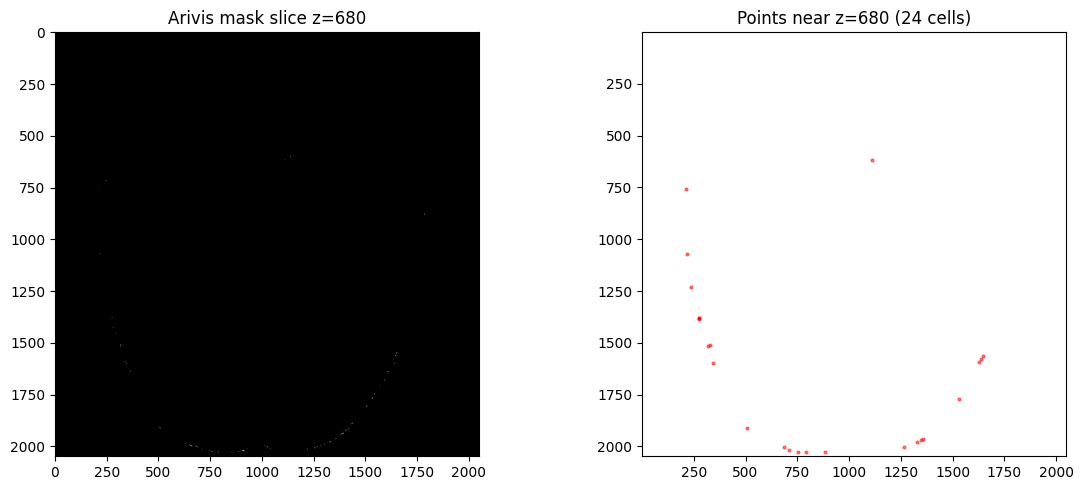

In [9]:
import matplotlib.pyplot as plt

# Pick a Z slice near the middle of the stack (1-based z for display)
z_show = nz // 2
z0 = z_show - 1  # 0-based index into mask stack

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

if BUILD_MASK and MASK_TIFF.is_file():
    with tifffile.TiffFile(MASK_TIFF) as tif:
        mask_slice = tif.pages[z0].asarray()
    axes[0].imshow(mask_slice, cmap="gray")
    axes[0].set_title(f"Arivis mask slice z={z_show}")
else:
    axes[0].set_title("No mask built")
    axes[0].axis("off")

if len(points_xyz):
    # Points within ±2 slices of z_show
    sel = np.abs(points_xyz[:, 2] - z_show) <= 2.0
    sub = points_xyz[sel]
    axes[1].scatter(sub[:, 0], sub[:, 1], s=4, c="red", alpha=0.5)
    axes[1].set_xlim(1, nx)
    axes[1].set_ylim(ny, 1)  # image coordinates: y increases downward
    axes[1].set_title(f"Points near z={z_show} ({sel.sum()} cells)")
else:
    axes[1].set_title("No points")

for ax in axes:
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 8. YAML snippet for `import-annotations`

Add this block to your brain config YAML (e.g. `examples/JulieBuron.yaml`), then run
**after** `lightsuite brain register`:

```bash
uv run lightsuite brain import-annotations -c examples/JulieBuron.yaml
```

Outputs land in `<save_path>/volume_registered/`.

In [10]:
import yaml

import_block = {
    "write_csv": True,
    "annotations": [
        {
            "format": "points_csv",
            "path": str(POINTS_CSV.resolve()),
            "label": f"{LABEL}_cells",
        },
    ],
}

if BUILD_MASK and MASK_TIFF.is_file():
    import_block["annotations"].append(
        {
            "format": "mask_tiff",
            "path": str(MASK_TIFF.resolve()),
            "label": f"{LABEL}_mask",
        }
    )

snippet_path = OUTPUT_DIR / "import_snippet.yaml"
snippet_path.write_text(yaml.dump({'import': import_block}, sort_keys=False), encoding="utf-8")
print("Copy into your config YAML:")
print()
print(yaml.dump({'import': import_block}, sort_keys=False))

Copy into your config YAML:

import:
  write_csv: true
  annotations:
  - format: points_csv
    path: /media/gbm/NVME2/ALICe-pipelines-data/JulieBuron/SegmentationImports/converted/arivis_561_points.csv
    label: arivis_561_cells
  - format: mask_tiff
    path: /media/gbm/NVME2/ALICe-pipelines-data/JulieBuron/SegmentationImports/converted/arivis_561_mask.tif
    label: arivis_561_mask



## 9. Test load with LightSuite adapters (optional)

Runs the same loaders used by `import-annotations` — useful to catch format errors before the full warp.

In [ ]:
from lightsuite.config.models import AnnotationFormat, AnnotationImportConfig
from lightsuite.import_.adapters import load_mask_tiff, load_points_csv, prepare_points_for_sample
from lightsuite.import_.sample_reference import SampleReference, validate_mask_against_reference

ref = SampleReference.load(ref_path)

pts_spec = AnnotationImportConfig(format=AnnotationFormat.POINTS_CSV, path=POINTS_CSV)
loaded_pts = load_points_csv(pts_spec)
prepared = prepare_points_for_sample(loaded_pts, reference=ref)
print(
    f"Points: {loaded_pts.coordinates.shape[0]} loaded, "
    f"{prepared.coordinates.shape[0]} in bounds, "
    f"{prepared.metadata.get('n_dropped', 0)} dropped"
)

if BUILD_MASK and MASK_TIFF.is_file():
    mask_spec = AnnotationImportConfig(format=AnnotationFormat.MASK_TIFF, path=MASK_TIFF)
    loaded_mask = load_mask_tiff(mask_spec)
    validate_mask_against_reference(loaded_mask.volume.shape, ref.voxel_um, ref)
    print(f"Mask: shape {loaded_mask.volume.shape}, foreground voxels {loaded_mask.volume.sum()}")

## Troubleshooting

| Symptom | Likely cause | Fix |
|---------|--------------|-----|
| Many points dropped | 0-based Arivis coords without `+1` | Re-run step 4 |
| Mask shape mismatch | Wrong Z count or segmented different stack | Re-export from Arivis on native grid |
| `openpyxl` errors on XLSX | Arivis styling | Use the XML reader in step 3 |
| Empty atlas mask after import | Registration / orientation issue | Re-run orientation + match-points |
| Segmented 20 µm preview TIFF | Coordinates not native resolution | Segment on full-res stack or rescale |

**Next:** complete `register`, then `uv run lightsuite brain import-annotations -c your_config.yaml`.